## Heart Variability

as a proxy for Symphatic Nervous System

Challenge: find out sampling rate
best current guess: 500
* tapas/PhysIO/code/readin/tapas_physio_read_physlogfiles_philips.m : %default: 500 Hz sampling frequency
* 500 in Gökis .json file,
* but with 400 it the HRV plot beneath looks closer to the tutorial example! (peak at ~ 600 RR-intervals)


In [64]:
import neurokit2 as nk
import pandas as pd
import numpy as np
import os.path as op
import os
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Users/mrenke/data/ds-stressrisk'


In [69]:
sub = '01'
ex_fn = f'/Users/mrenke/data/ds-stressrisk/sub-{sub}/ses-1/func/sub-{sub}_ses-1_task-risk_run-1_physio.log'
ex_df = pd.read_csv(ex_fn, delim_whitespace=True, header=4) # '\t'
ex_df.columns = list(ex_df.columns[1:]) + ['']
ex_df = ex_df.drop(columns='')
ex_df = ex_df.apply(pd.to_numeric, errors='coerce')

ex_df.head()

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_2481/417087747.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ex_df = pd.read_csv(ex_fn, delim_whitespace=True, header=4) # '\t'


,v1raw,v2raw,v1,v2,ppu,resp,gx,gy,gz,mark
0,550.0,-343.0,481.0,-216.0,0.0,914.0,0.0,0.0,0.0,0.0
1,560.0,-373.0,498.0,-258.0,0.0,914.0,0.0,0.0,0.0,0.0
2,567.0,-397.0,511.0,-295.0,0.0,913.0,0.0,0.0,0.0,0.0
3,569.0,-418.0,519.0,-327.0,0.0,913.0,0.0,0.0,0.0,0.0
4,569.0,-433.0,523.0,-354.0,0.0,913.0,0.0,0.0,0.0,0.0


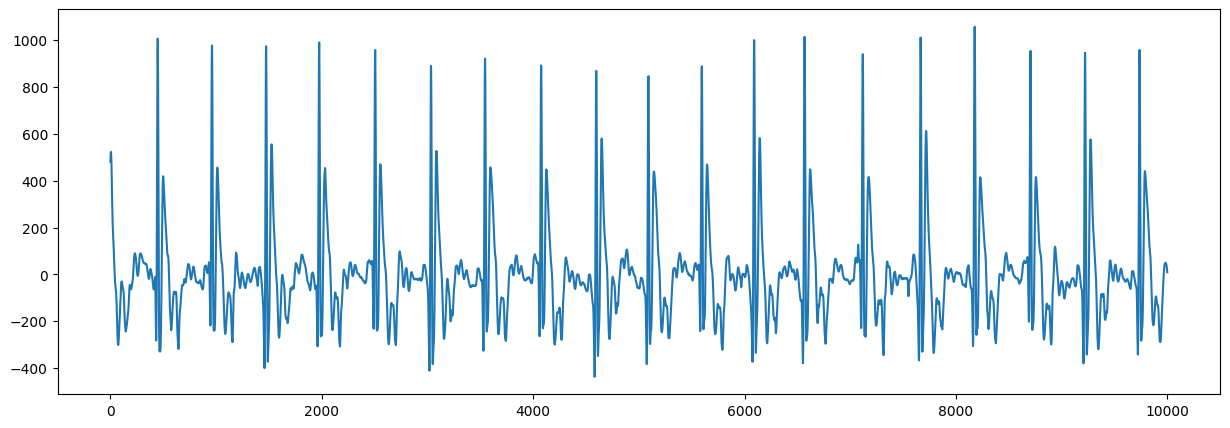

In [75]:
var = 'v1'

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(ex_df[var][:10000])

In [82]:
var = 'v2'
sampling_rate = 500
ecg_signal = ex_df[var].values
peaks, info = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate) # occurences of R-peaks are marked with 1 in a list of zeros; dictionary of the sample points at which these R-peaks occur

HRV is the temporal variation between consecutive heartbeats (RR intervals)

* RMSSD (square root of the mean of the sum of successive differences between adjacent RR intervals), 
* MeanNN (mean of RR intervals) 

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN
0,829.228571,226.349042,NaN,NaN,NaN,NaN,NaN,NaN,271.623781,273.607737,...,383.5,0.833318,555.2,1010.0,64.285714,82.857143,414.0,1098.0,17.5,0.0


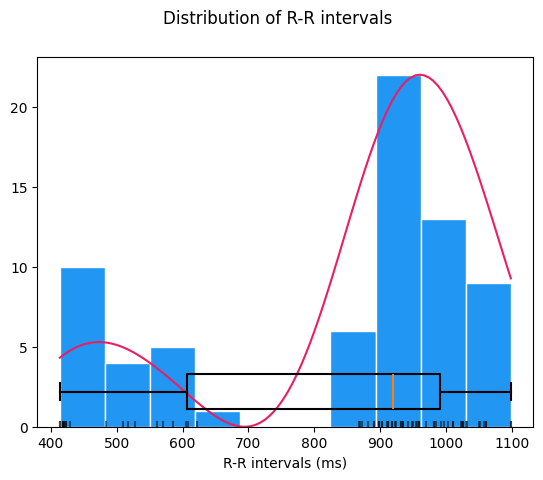

In [83]:
# Extract clean EDA and SCR features
hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=True)
hrv_time

0    0.131804
Name: HRV_LFHF, dtype: float64

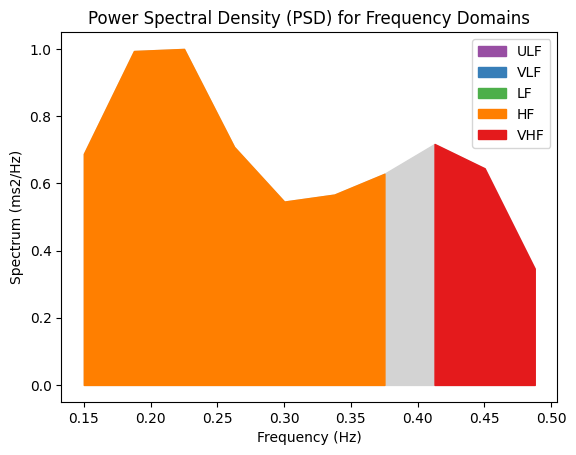

In [84]:
# Frequency domain analysis

hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sampling_rate, show=True, normalize=True)
hrv_freq['HRV_LFHF']

In [85]:
hrv_freq

,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF
0,NaN,NaN,0.011553,0.087651,0.035284,0.134488,0.131804,0.085902,0.65174,-2.434393


In [86]:
hrv_freq['HRV_LF']/hrv_freq['HRV_HF']

0    0.131804
dtype: float64

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,3132.021277,1009.521956,137.895777,1017.687897,NaN,NaN,NaN,NaN,1124.00111,1130.092784,...,0.64623,5.938905,0.782084,0.742149,1.204428,1.378084,1.08304,1.762859,4.806948,0.767026


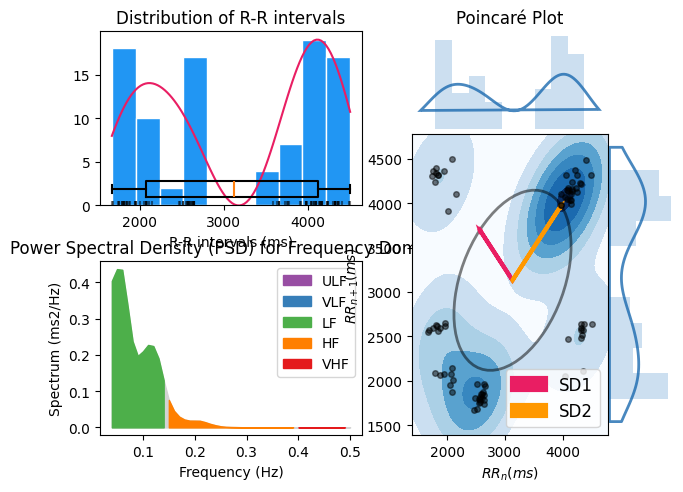

In [63]:
hrv_indices = nk.hrv(peaks, sampling_rate=100, show=True)
hrv_indices